Import Libaries

In [1]:
import pandas as pd  
import matplotlib.pyplot as plt  

from sklearn.model_selection import train_test_split  
from sklearn.linear_model import LinearRegression  
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score   

Load dataset

In [2]:
filepath = "advertising.csv" 
try: 
    df = pd.read_csv(filepath) 
except Exception as e: 
    print("Error:", e) 

df = pd.read_csv(filepath) 
df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [3]:
df.info()
print("++++++++++++++++++++++++++++")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
++++++++++++++++++++++++++++


,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


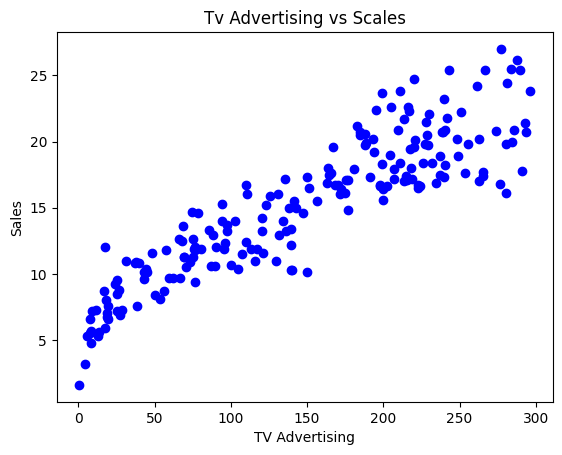

In [4]:
plt.scatter(df["TV"], df["Sales"], color="blue")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Tv Advertising vs Scales")
plt.show()

In [5]:
x= df[["TV"]]
y= df["Sales"]

In [6]:
model = LinearRegression()

In [7]:
model.fit(x,y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [8]:
m = model.coef_[0]
c = model.intercept_
print("Coefficient (m):", f"{m:.4f}")
print("Intercept (c):", f"{c:.4f}")
print("Best fit equation is: y =", f"{m:.4f}", "* x +", f"{c:.4f}")

Coefficient (m): 0.0555
Intercept (c): 6.9748
Best fit equation is: y = 0.0555 * x + 6.9748


In [11]:
y_pred = model.predict(x)
print("Predicted values:", y_pred[:5])


Predicted values: [19.73726517  9.44300377  7.92881554 15.37773421 17.00285199]


In [12]:
mse= mean_squared_error(y, y_pred)
print("Mean Squared Error:", mse)

r2 = r2_score(y, y_pred)
print("R2 Score:", r2 )

Mean Squared Error: 5.2177438977951285
R2 Score: 0.8121757029987414


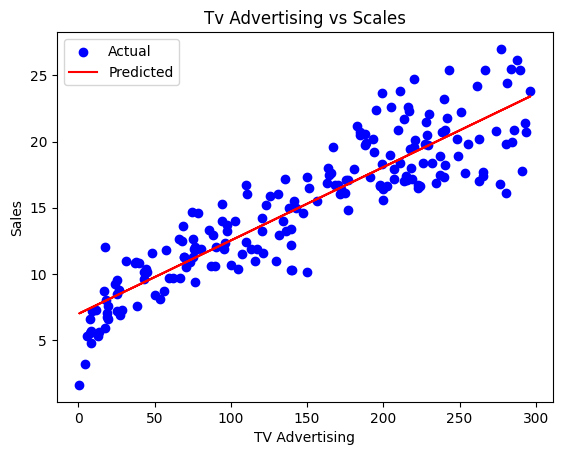

In [13]:
plt.scatter(x, y, color="blue", label="Actual")
plt.plot(x, y_pred, color="red", label="Predicted")
plt.xlabel("TV Advertising")
plt.ylabel("Sales")
plt.title("Tv Advertising vs Scales")
plt.legend()
plt.show()

In [14]:
residuals = y - y_pred
df["Predicted"] = y_pred
df["Residuals"] = residuals
df["Residuals_Squared"] = residuals ** 2
print(df[["TV", "Sales", "Predicted", "Residuals", "Residuals_Squared"]].head())

      TV  Sales  Predicted  Residuals  Residuals_Squared
0  230.1   22.1  19.737265   2.362735           5.582516
1   44.5   10.4   9.443004   0.956996           0.915842
2   17.2   12.0   7.928816   4.071184          16.574543
3  151.5   16.5  15.377734   1.122266           1.259480
4  180.8   17.9  17.002852   0.897148           0.804875


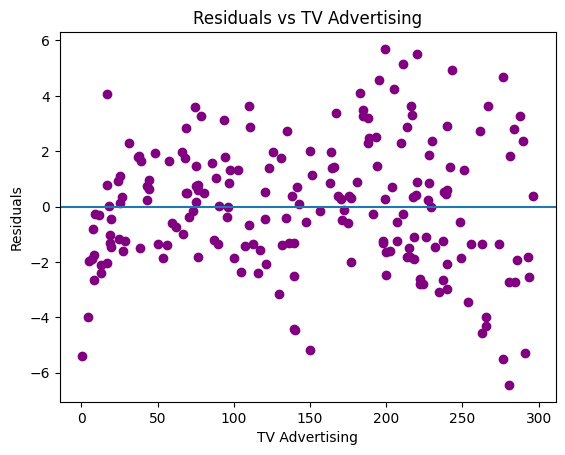

In [17]:
plt.scatter(df["TV"] , residuals, color="purple")
plt.axhline(0)
plt.xlabel("TV Advertising")
plt.ylabel("Residuals") 
plt.title("Residuals vs TV Advertising")
plt.show()
